# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [2]:
# Install PyTorch
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (26 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.6 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl (178.7 MB)
Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl (1.8 MB)
Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp3

Iteration 0, Loss: 1.053398609161377
Iteration 100, Loss: 0.9789832830429077
Iteration 200, Loss: 0.8923161029815674
Iteration 300, Loss: 0.7617807388305664
Iteration 400, Loss: 0.620663583278656
Iteration 500, Loss: 0.5089000463485718
Iteration 600, Loss: 0.4311419129371643
Iteration 700, Loss: 0.375917911529541
Iteration 800, Loss: 0.3300807476043701
Iteration 900, Loss: 0.2952294945716858
Iteration 1000, Loss: 0.27163103222846985
Iteration 1100, Loss: 0.25304651260375977
Iteration 1200, Loss: 0.2391231209039688
Iteration 1300, Loss: 0.22883197665214539
Iteration 1400, Loss: 0.22033123672008514
Iteration 1500, Loss: 0.21290194988250732
Iteration 1600, Loss: 0.2065552920103073
Iteration 1700, Loss: 0.2010192722082138
Iteration 1800, Loss: 0.19593432545661926
Iteration 1900, Loss: 0.19084830582141876
Iteration 2000, Loss: 0.1832328736782074
Iteration 2100, Loss: 0.17800000309944153
Iteration 2200, Loss: 0.1730545312166214
Iteration 2300, Loss: 0.16827081143856049
Iteration 2400, Loss: 

/srv/conda/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


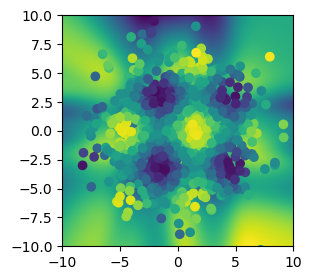

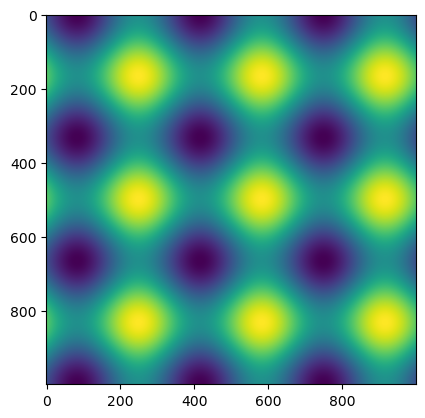

In [5]:
# Get our data
import data

# lets look at the data
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)

# Build the model
import torch

model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for t in range(10000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()

What is the difference between artificial intelligence, machine learning and deep learning?

In [ ]:
# AI is like a large umbrella term for computer science that makes machines that "reason" and "learn" by detecting patterns and assuming the next word.
# ML uses algorithms to find patterns in data to make predictions/descisions. So it can like "learn" from the data without explicitly being programmed.
# DL is an advanced form of ML that uses neural networks to process large amounts of data. It can be used to deal with unstructured data like images, audio and text.

What is a neural network?

In [ ]:
# A type of machine learning model that is supposed to model the human brain. It uses nodes to input the data and process it and output it to the next layer.
# They process data and detect patterns and are the foundation for deep learning.

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [3]:
# 2 represents the number of input features (the size of the inmput layer)
# 50 the number of output features (the size of the next/following layers)

What does the activation function do?

In [ ]:
# It introduces non-linearity into the neural network so it can learn from more complex patterns in data.

What is a loss function? Why do we need one?

In [4]:
# A loss function measures how well a neural network's predictions math the actual values.
# It gives us a value for the error and can help the model improve.
# Without the loss function, the neural network would't know how far off its predictions are or how to improve.

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [5]:
# We call it to clear the gradients from the previous iteration before performing backpropagation.
# It also prevents gradients moxing because if they arent cleared, there would be wrong weight updates.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

Iteration 0, Loss: 1.072785496711731
Iteration 100, Loss: 0.4351033568382263
Iteration 200, Loss: 0.24917082488536835
Iteration 300, Loss: 0.17640617489814758
Iteration 400, Loss: 0.10720265656709671
Iteration 500, Loss: 0.08408883959054947
Iteration 600, Loss: 0.07061035186052322
Iteration 700, Loss: 0.06032994017004967
Iteration 800, Loss: 0.048674218356609344
Iteration 900, Loss: 0.039412979036569595


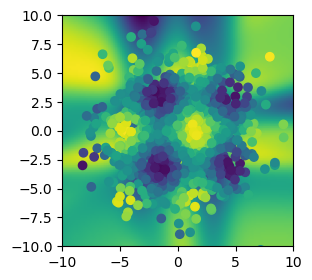

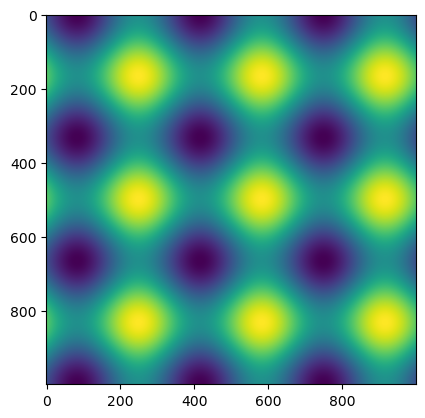

In [6]:
# Get our data
import data

# lets look at the data
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)

# Build the model
import torch

model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

# Train our model
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-2)

for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# evaluate
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim = 2)

output = model(grid).detach()
plt.imshow(output, extent = (-10, 10, -10, 10))
plt.show()

plt.imshow(data.pattern)
plt.show()

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [7]:
# The loss functions are way larger.
# With 50 neurons it was like 0.4-0.3 and with 30 its 1.1-0.4. 
# So, the loss is generally larger and way more spaced out.

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [8]:
# Loss function with the change are like 1.1-0.3.
# The one from lecture was like 0.4-0.3
# So, the lecture one was way more narrowed and smaller vs the change right now shows much larger values and way spread apart.

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [9]:
# The loss function now ranges from like 1.14-0.25.
# the loss function from lecture was 0.4-0.3
# So, there is like a wayyyyy larger range on the loss function now and the values are way more spread apart.

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [10]:
# Sigmoid function squashes outputs between 0 and 1, and is used in binary classification problems. 
# ReLU outputs zero for negative inputs and retains positive values, making it more efficient, though it can suffer from "dying ReLU" problem.
# Tanh is similar to Sigmoid but squashes outputs between -1 and 1, helping center data around zero
# ReLU is generally preferred for deep learning because it avoids the vanishing gradient problem
# Sigmoid and Tanh are often used in specific cases like binary classification and recurrent networks.

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [11]:
# Code now: 1.13-0.06
# Code from lecture: 0.4-0.3

Modify your model to have **two hidden layers** instead of one. Give that code here.

In [12]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  # First hidden layer
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 30),  # Second hidden layer
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)   # Output layer
)

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [13]:
import new_data

Define a new model and train it **poorly** in the cell below.

Iteration 0, Loss: 1.344660997390747
Iteration 20, Loss: 0.8685005307197571
Iteration 40, Loss: 0.4021005630493164
Iteration 60, Loss: 0.36251673102378845
Iteration 80, Loss: 0.33897486329078674


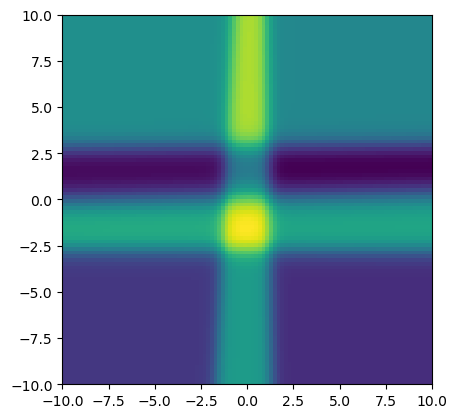

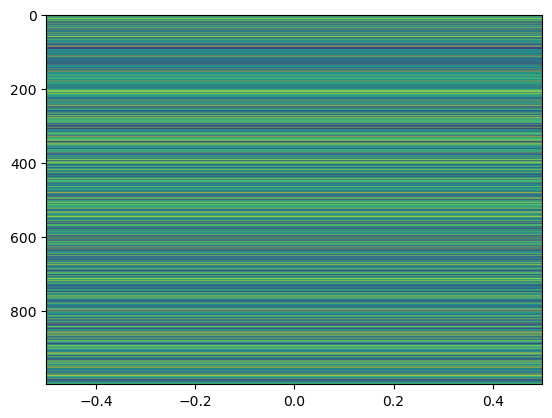

In [7]:
import importlib
import new_data
importlib.reload(new_data)

# Define a weak model
weak_model = torch.nn.Sequential(
    torch.nn.Linear(2, 5),  # like 0 neurons so the model is gonna be trash
    torch.nn.Sigmoid(),
    torch.nn.Linear(5, 1)
)

# Use a high learning rate but a weak optimizer
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(weak_model.parameters(), lr = 0.5)  # super high learning rate

# Poorly train the model (too few iterations)
for t in range(100):
    y_pred = weak_model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 20 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# plot it!
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = weak_model(grid).detach()
plt.imshow(output, extent=(-10, 10, -10, 10))
plt.show()

plt.imshow(new_data.color_values.reshape(1000, 1), aspect='auto')
plt.show()

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

Iteration 0, Loss: 1.0850303173065186
Iteration 100, Loss: 0.7564846277236938
Iteration 200, Loss: 0.3684881627559662
Iteration 300, Loss: 0.2314690202474594
Iteration 400, Loss: 0.1801319122314453
Iteration 500, Loss: 0.15524420142173767
Iteration 600, Loss: 0.13989399373531342
Iteration 700, Loss: 0.12784595787525177
Iteration 800, Loss: 0.11793118715286255
Iteration 900, Loss: 0.11035702377557755


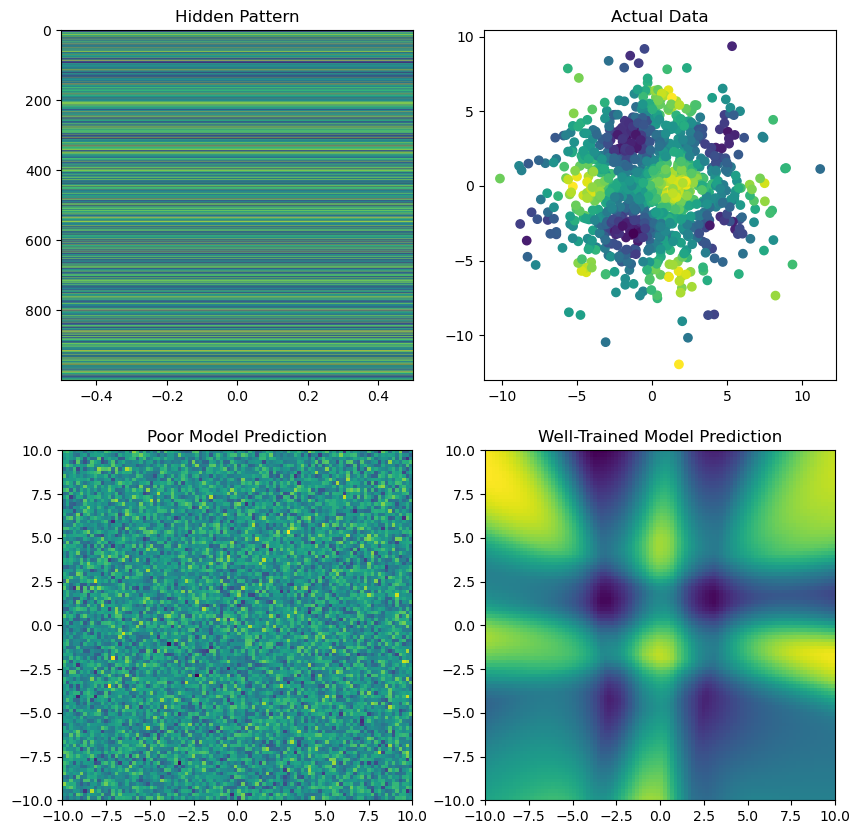

In [8]:
import torch
import matplotlib.pyplot as plt
import new_data

# Define a way better-structured model
better_model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),  # More neurons
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

# Training the improved model
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(better_model.parameters(), lr=1e-3)

for t in range(1000):  # More iterations
    y_pred = better_model(new_data.x)
    loss = loss_fn(y_pred, new_data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if t % 100 == 0:
        print(f'Iteration {t}, Loss: {loss.item()}')

# Make predictions
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

poor_output = torch.randn_like(grid[..., :1])  # poor model output
better_output = better_model(grid).detach()

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Top Left = Hidden Pattern
axes[0, 0].imshow(new_data.color_values.reshape(1000, 1), aspect='auto')
axes[0, 0].set_title("Hidden Pattern")

# Top Right = Actual Data
axes[0, 1].scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)
axes[0, 1].set_title("Actual Data")

# Bottom Left = Poorly Trained Model Prediction
axes[1, 0].imshow(poor_output.numpy(), extent=(-10, 10, -10, 10))
axes[1, 0].set_title("Poor Model Prediction")

# Bottom Right = Well-Trained Model Prediction
axes[1, 1].imshow(better_output.numpy(), extent=(-10, 10, -10, 10))
axes[1, 1].set_title("Well-Trained Model Prediction")

plt.show()

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

Epoch [100/1000], Loss: 379.4064
Epoch [200/1000], Loss: 288.7656
Epoch [300/1000], Loss: 194.7080
Epoch [400/1000], Loss: 141.5928
Epoch [500/1000], Loss: 125.7887
Epoch [600/1000], Loss: 121.0701
Epoch [700/1000], Loss: 118.1389
Epoch [800/1000], Loss: 115.7326
Epoch [900/1000], Loss: 113.6074
Epoch [1000/1000], Loss: 111.7499
Mean Squared Error on Test Set: 112.7184


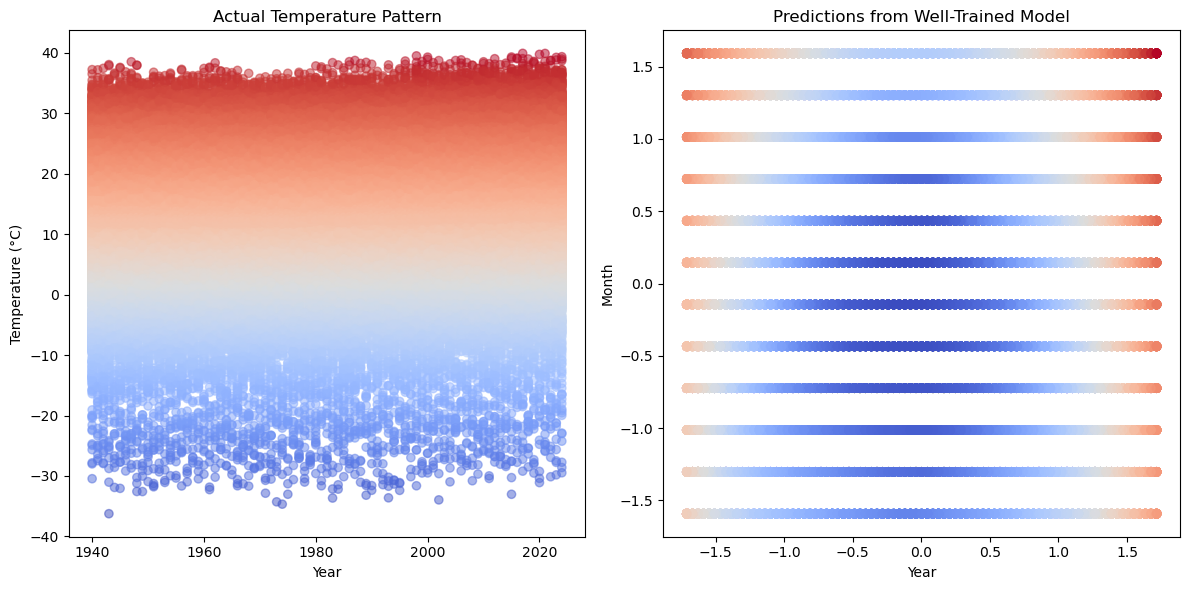

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
file_path = 'average-monthly-surface-temperature.csv'
data = pd.read_csv(file_path)

# Preprocess the data
data['Day'] = pd.to_datetime(data['Day'])
data['Year'] = data['Day'].dt.year
data['Month'] = data['Day'].dt.month
X = data[['Year', 'Month']].values
y = data['Average surface temperature'].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Define the neural network model
class TemperaturePredictor(nn.Module):
    def __init__(self):
        super(TemperaturePredictor, self).__init__()
        self.fc1 = nn.Linear(2, 50)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(50, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Define loss function and optimizer
model = TemperaturePredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    mse = criterion(predictions, y_test_tensor)
    print(f'Mean Squared Error on Test Set: {mse.item():.4f}')

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Change to 1 row, 2 columns

# (Left) The actual pattern of temperature over time
axes[0].scatter(data['Year'], data['Average surface temperature'], c=data['Average surface temperature'], cmap='coolwarm', alpha=0.5)
axes[0].set_title("Actual Temperature Pattern")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Temperature (°C)")

# (Right) Predictions from the well-trained model
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=predictions.detach().numpy(), cmap='coolwarm', alpha=0.5)
axes[1].set_title("Predictions from Well-Trained Model")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Month")

plt.tight_layout()
plt.show()

In [ ]:
# I found my data from Kaggle lol, it's about average monthly surface temperatures
# The model got like a mean squared error of like 112 on the test set lmao
# This should mean that tha data fits like really badly, which you clearly can see it doesnt fit well, but i cant figure out how to fix it

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!